# 01 — Lung Cancer Risk: Classical ML

**Component 1 of 4 — RespiraAI Deployment Capstone**

Trains a classical ML baseline (Logistic Regression + Random Forest) on the real [Lung Cancer Survey dataset](https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer) (309 patients, 15 symptom/lifestyle features, binary target). This notebook and `02_lung_cancer_dl.ipynb` solve the *exact same task* on the *exact same data* with the *exact same train/test split* — the point is a direct, fair ML-vs-DL comparison once both are done.


In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay

RANDOM_STATE = 42  # fixed everywhere so the DL notebook can reproduce the identical split


## Data loading

Same dynamic-path pattern worth using in any notebook you'll hand off or move between machines: try a few likely locations instead of hardcoding one path that breaks the moment someone opens the notebook from a different working directory.

In [3]:
def find_data_file(filename):
    candidates = [
        filename,
        os.path.join("data", filename),
        os.path.join("day1_data", "data", filename),
        os.path.join("..", "data", filename),
        os.path.join(".", filename),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(
        f"Could not find {filename!r} in any of: {candidates}. "
        "Place lung_cancer.csv in a data/ folder next to (or above) this notebook."
    )

df = pd.read_csv(find_data_file("lung_cancer.csv"))
print(df.shape)
df.head()


(309, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


## EDA

First and most important thing to check on any classification dataset: how imbalanced is the target?

['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER']

Class balance:
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64
LUNG_CANCER
YES    0.874
NO     0.126
Name: proportion, dtype: float64


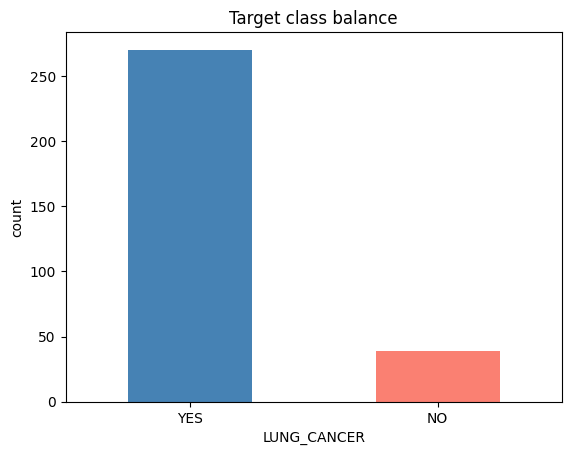

In [4]:
# Normalize column names: strip whitespace, uppercase, spaces -> underscores
df.columns = [c.strip().upper().replace(" ", "_") for c in df.columns]
print(df.columns.tolist())

print("\nClass balance:")
print(df["LUNG_CANCER"].value_counts())
print(df["LUNG_CANCER"].value_counts(normalize=True).round(3))

# 270 YES vs 39 NO -> ~87% positive class. This is a real, meaningfully imbalanced
# dataset, not a toy 50/50 one -- worth keeping in mind for every metric below:
# plain accuracy will look good even from a model that just predicts YES every time.
df["LUNG_CANCER"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Target class balance")
plt.xticks(rotation=0)
plt.ylabel("count")
plt.show()


In [5]:
df.describe()


,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


## Preprocessing

The raw data encodes `GENDER` as M/F and every symptom column as 1/2 (not 0/1) with `LUNG_CANCER` as YES/NO text. None of that is model-ready, so it all needs explicit, documented conversion — guessing at an encoding silently is how you end up with a model that's backwards.

In [6]:
df["GENDER"] = df["GENDER"].map({"M": 1, "F": 0})
df["LUNG_CANCER"] = df["LUNG_CANCER"].map({"YES": 1, "NO": 0})

# Every symptom/lifestyle column is 1=No, 2=Yes in the raw data -> shift to standard 0/1
symptom_cols = [c for c in df.columns if c not in ("GENDER", "AGE", "LUNG_CANCER")]
for c in symptom_cols:
    df[c] = df[c] - 1

assert df[symptom_cols].isin([0, 1]).all().all(), "symptom columns should now be strictly 0/1"
df.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [7]:
FEATURE_COLUMNS = [c for c in df.columns if c != "LUNG_CANCER"]  # save for the DL notebook / API to reuse

X = df[FEATURE_COLUMNS]
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)
print("train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("test class balance: ", y_test.value_counts(normalize=True).round(3).to_dict())
# stratify=y keeps the ~87/13 split consistent between train and test


train: (247, 15)  test: (62, 15)
train class balance: {1: 0.874, 0: 0.126}
test class balance:  {1: 0.871, 0: 0.129}


## Train: Logistic Regression + Random Forest

`class_weight='balanced'` on both models — without it, both would happily predict YES for almost everyone and still post a deceptively high accuracy, given the 87/13 imbalance above.

In [8]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results[name] = {"accuracy": acc, "f1": f1, "preds": preds}
    print(f"\n=== {name} ===  accuracy={acc:.3f}  f1={f1:.3f}")
    print(classification_report(y_test, preds, target_names=["NO", "YES"]))



=== logistic_regression ===  accuracy=0.855  f1=0.909
              precision    recall  f1-score   support

          NO       0.47      1.00      0.64         8
         YES       1.00      0.83      0.91        54

    accuracy                           0.85        62
   macro avg       0.74      0.92      0.77        62
weighted avg       0.93      0.85      0.87        62


=== random_forest ===  accuracy=0.903  f1=0.944
              precision    recall  f1-score   support

          NO       0.62      0.62      0.62         8
         YES       0.94      0.94      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.78      0.78        62
weighted avg       0.90      0.90      0.90        62



## Evaluation detail

The single most clinically relevant number here is **recall on the NO class** — how many of the genuinely cancer-free patients does each model correctly clear, versus how many does it needlessly flag? Look at that column specifically, not just overall accuracy.

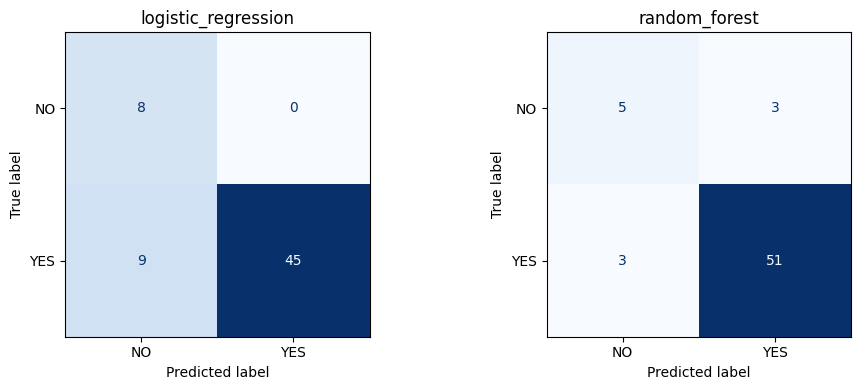

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, display_labels=["NO", "YES"], ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


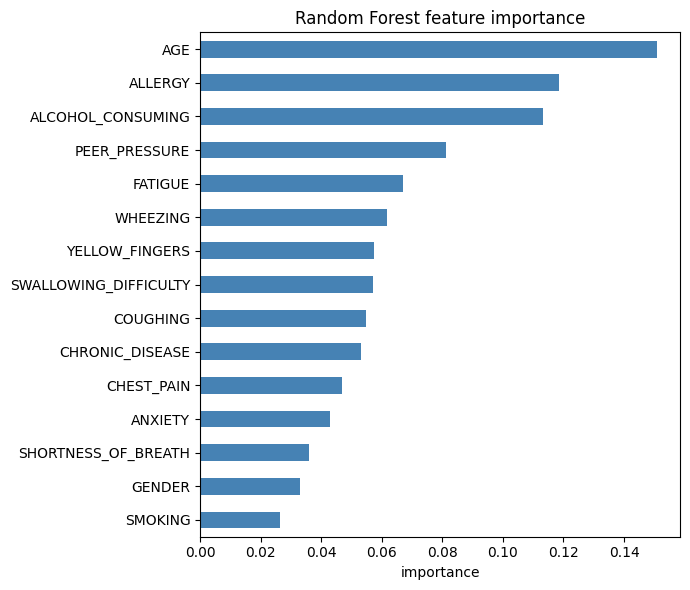

In [10]:
# Random Forest feature importance -- which symptoms actually drive the prediction?
rf = models["random_forest"]
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()

importances.plot(kind="barh", figsize=(7, 6), color="steelblue")
plt.title("Random Forest feature importance")
plt.xlabel("importance")
plt.tight_layout()
plt.show()


## Save the model

Saved for the FastAPI backend to load at startup (see the deployment plan — models are loaded once, not per-request).

In [11]:
os.makedirs("../models", exist_ok=True) if os.path.isdir("..") else os.makedirs("models", exist_ok=True)
MODELS_DIR = "../models" if os.path.isdir("../models") else "models"

joblib.dump(models["random_forest"], os.path.join(MODELS_DIR, "lung_cancer_rf.pkl"))
joblib.dump(FEATURE_COLUMNS, os.path.join(MODELS_DIR, "lung_cancer_feature_columns.pkl"))
print(f"Saved random_forest model + feature column order to {MODELS_DIR}/")

# Random Forest is the one that ships to the API: comparable F1 to Logistic Regression
# here, and (unlike LogReg) needs no separate feature-scaling step at inference time,
# which keeps the FastAPI predict endpoint simpler.


Saved random_forest model + feature column order to ../models/


## Notes

- **Class imbalance (270 YES / 39 NO) is the dominant fact about this dataset.** Every metric above was read with that in mind — `class_weight='balanced'` compensates for it during training, but always check per-class recall/precision, never just accuracy, on data shaped like this.
- Random Forest and Logistic Regression land at similar overall F1 here; the more interesting comparison is how each handles the minority (NO) class — worth checking your own run's confusion matrices above rather than assuming one is strictly better.
- Feature importance gives a sanity check as much as an insight: if something clinically implausible (like `GENDER` alone) dominated the importances, that would be a signal to go back and check the preprocessing rather than trust the model.
- Next: `02_lung_cancer_dl.ipynb` repeats this exact task with a small PyTorch MLP, using the same `RANDOM_STATE=42` split, for a direct ML-vs-DL comparison on identical data.